In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from SyntheticControlMethods import Synth

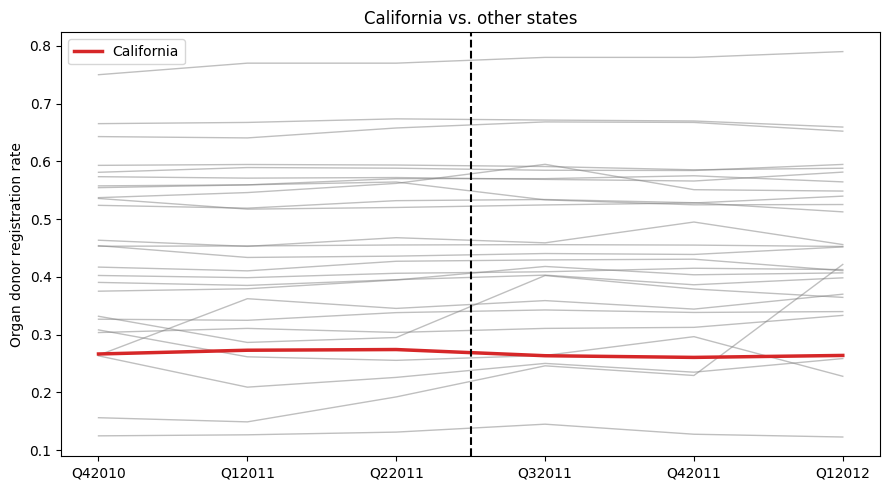

In [10]:

from causaldata import organ_donations

df = organ_donations.load_pandas().data

fig, ax = plt.subplots(figsize=(9, 5))

# Comparison states in grey
for state, g in df[df.State != "California"].groupby("State"):
    ax.plot(g.Quarter_Num, g.Rate, color="grey", alpha=0.5, lw=1)

# California on top
ca = df[df.State == "California"]
ax.plot(ca.Quarter_Num, ca.Rate, color="C3", lw=2.5, label="California")

# Policy took effect in Q3 2011 (Quarter_Num 4), so draw the line just before it
ax.axvline(3.5, ls="--", color="black")

# Use the quarter labels on the x-axis
labels = df.drop_duplicates("Quarter_Num").sort_values("Quarter_Num")
ax.set_xticks(labels.Quarter_Num)
ax.set_xticklabels(labels.Quarter)

ax.set_ylabel("Organ donor registration rate")
ax.set_title("California vs. other states")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:


import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from causaldata import organ_donations

# =====================================================================
# SETUP
# =====================================================================
# One row per state per quarter: 27 states x 6 quarters (Q4 2010 to Q1 2012).
# Rate is the share of people registered as organ donors.
# California switched to "active choice" (people must decide when renewing a
# licence, instead of opting in later) in Q3 2011. We want to know whether
# that policy changed registration.
df = organ_donations.load_pandas().data

# DiD needs two labels for every row:
#   - which group is treated (who got the policy)
#   - which period is after the policy
df["treat"] = (df.State == "California").astype(int)   # 1 for California, 0 for the rest
df["post"] = (df.Quarter_Num >= 4).astype(int)         # Quarter_Num 4 = Q3 2011, the start date

# The "did" variable is 1 only for California after the policy began.
# It marks exactly the rows where the policy is in effect, which is why
# its coefficient later on is the treatment effect.
df["did"] = df.treat * df.post

# Standard errors are clustered by state because a state's outcomes are
# correlated over time (a state with a high rate stays high). Ignoring this
# makes the standard errors too small. statsmodels needs numeric group ids.
groups = pd.factorize(df.State)[0]

# =====================================================================
# 1) THE 2x2 TABLE OF MEANS
# =====================================================================
# DiD is built from four averages: treated/control, before/after.
# The estimate is (California after - California before)
#               - (others after - others before).
# Subtracting the control group's change removes anything that moved all
# states at the same time (seasonality, national trends). Subtracting each
# group's own starting level removes permanent differences between them
# (California just has a lower baseline rate). What's left is the change
# specific to California after the policy.
print(df.groupby(["treat", "post"]).Rate.mean())

# =====================================================================
# 2) THE SAME THING AS A REGRESSION
# =====================================================================
# "treat*post" expands to treat + post + treat:post. Each term has a meaning:
#   treat       the permanent gap between California and the others
#   post        the common change over time that affects everyone
#   treat:post  the extra change in California after the policy (the DiD estimate)
# Running it as a regression gives standard errors and lets us add controls later.
m1 = smf.ols("Rate ~ treat*post", df).fit(
    cov_type="cluster", cov_kwds={"groups": groups})
print(m1.summary().tables[1])

# =====================================================================
# 3) FIXED EFFECTS VERSION
# =====================================================================
# Here we replace treat and post with a dummy for every state and every quarter.
#   C(State)        absorbs each state's permanent level (what "treat" did before)
#   C(Quarter_Num)  absorbs each quarter's common shock (what "post" did before)
# With one policy date and a balanced panel, the answer is identical to the
# simple version. This form matters when you have several treated units or
# several adoption dates, so it's worth learning now.
m2 = smf.ols("Rate ~ did + C(State) + C(Quarter_Num)", df).fit(
    cov_type="cluster", cov_kwds={"groups": groups})
print(m2.params["did"], m2.bse["did"])

# =====================================================================
# 4) EVENT STUDY
# =====================================================================
# The estimate above averages all post-policy quarters into one number and
# says nothing about whether the groups were already diverging before the
# policy. An event study gives California its own coefficient in every quarter.
#   Pre-policy coefficients near zero: no sign the groups were drifting apart,
#   which supports the parallel-trends assumption DiD relies on.
#   Post-policy coefficients: how the effect develops over time.
# Quarter_Num 3 (Q2 2011) is left out on purpose. Every coefficient is measured
# relative to it, and the model can't be estimated with all quarters included.
ks = [1, 2, 4, 5, 6]
for k in ks:
    df[f"q{k}"] = ((df.Quarter_Num == k) & (df.treat == 1)).astype(int)
m3 = smf.ols("Rate ~ " + " + ".join(f"q{k}" for k in ks)
             + " + C(State) + C(Quarter_Num)", df).fit(
    cov_type="cluster", cov_kwds={"groups": groups})
print(m3.params[[f"q{k}" for k in ks]])

# =====================================================================
# 5) PLACEBO TEST (HOW UNUSUAL IS CALIFORNIA?)
# =====================================================================
# Clustered standard errors don't work well when only one unit is treated:
# the cluster-based formula needs many treated clusters to be accurate.
# A placebo test avoids that. We pretend each other state received the policy
# and compute the same DiD estimate for it. Those estimates show how big a
# "gap" appears by chance, since none of those states had the policy.
# If California's estimate sits well outside that distribution, the effect
# is hard to blame on noise. If it sits inside, it isn't.
est = {}
for s in df.State.unique():
    d = df.copy()
    d["did"] = (d.State == s).astype(int) * d.post    # pretend state s is treated
    est[s] = smf.ols("Rate ~ did + C(State) + C(Quarter_Num)", d).fit().params["did"]

# Share of states with a gap at least as large (in absolute size) as California's.
# This is a permutation p-value: small means California is unusual.
print(np.mean(np.abs(list(est.values())) >= abs(est["California"])))

# Which states have the most negative placebo "effects"
print(sorted(est.items(), key=lambda x: x[1])[:3])

treat  post
0      0       0.444931
       1       0.458856
1      0       0.271333
       1       0.262800
Name: Rate, dtype: float64
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4449      0.031     14.171      0.000       0.383       0.506
treat         -0.1736      0.031     -5.529      0.000      -0.235      -0.112
post           0.0139      0.006      2.293      0.022       0.002       0.026
treat:post    -0.0225      0.006     -3.698      0.000      -0.034      -0.011
-0.022458974358974558 0.006720765526939176
q1   -0.002942
q2    0.006296
q4   -0.021565
q5   -0.020292
q6   -0.022165
dtype: float64


/usr/local/lib/python3.10/site-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  res = self.wald_test(


0.18518518518518517
[('New Hampshire', -0.04745128205128239), ('South Carolina', -0.026370512820513163), ('California', -0.022458974358974558)]


# 1) 2x2 table of mean registration rates
treat  post
0      0       0.444931    # other states, before: 44.5%
       1       0.458856    # other states, after: 45.9% (up 1.4 points)
1      0       0.271333    # California, before: 27.1%
       1       0.262800    # California, after: 26.3% (down 0.9 points)
# DiD = (0.2628 - 0.2713) - (0.4589 - 0.4449) = -0.0225

# 2) Regression version
                 coef    std err          z      P>|z|      [0.025      0.975]
Intercept      0.4449      0.031     14.171      0.000       0.383       0.506   # other states' pre-period mean
treat         -0.1736      0.031     -5.529      0.000      -0.235      -0.112   # California started 17 points lower
post           0.0139      0.006      2.293      0.022       0.002       0.026   # common time trend: +1.4 points
treat:post    -0.0225      0.006     -3.698      0.000      -0.034      -0.011   # the DiD estimate: -2.25 points

# 3) With fixed effects: same estimate, as expected with one policy date
-0.0224589743589747 0.006720765526939197    # coefficient, clustered SE

# 4) Event study (relative to Q2 2011)
q1   -0.002942    # Q4 2010: near zero, as hoped
q2    0.006296    # Q1 2011: near zero
q4   -0.021565    # Q3 2011: drop starts when the policy starts
q5   -0.020292    # Q4 2011: stays down
q6   -0.022165    # Q1 2012: stays down

# 5) Placebo test
0.18518518518518517                         # share of states with a gap as large as California's
[('New Hampshire', -0.0475), ('South Carolina', -0.0264), ('California', -0.0225)]

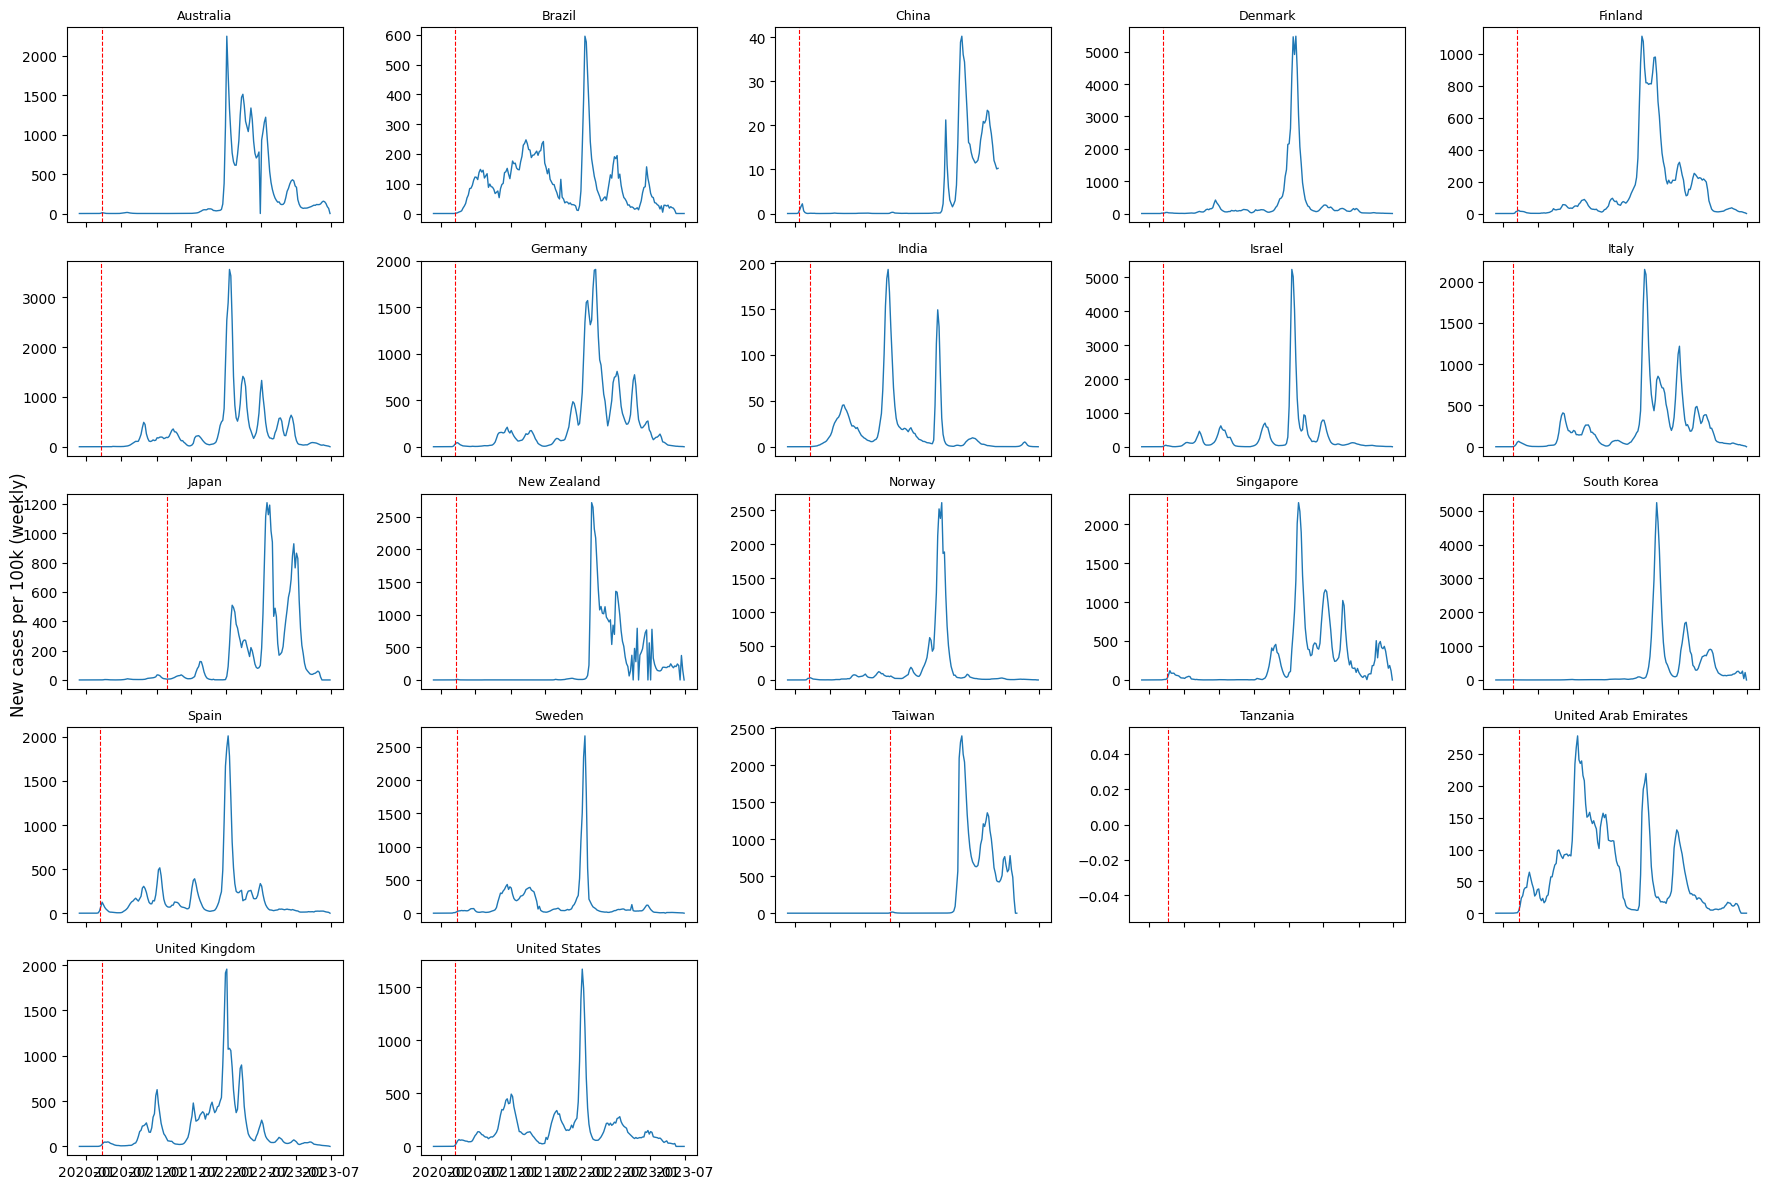

In [20]:
df = pd.read_csv("covid_did_weekly.csv", parse_dates=["week_start", "policy_date_s50"])
df.loc[df.data_flag.notna(), "new_cases_per_100k"] = None  # drop flagged rows

countries = sorted(df.country.unique())
fig, axes = plt.subplots(5, 5, figsize=(18, 12), sharex=True)

for ax, c in zip(axes.flat, countries):
    d = df[df.country == c]
    ax.plot(d.week_start, d.new_cases_per_100k, lw=1)
    ax.axvline(d.policy_date_s50.iloc[0], color="red", ls="--", lw=0.8)
    ax.set_title(c, fontsize=9)

for ax in axes.flat[len(countries):]:
    ax.axis("off")
fig.supylabel("New cases per 100k (weekly)")
plt.tight_layout()
plt.show()

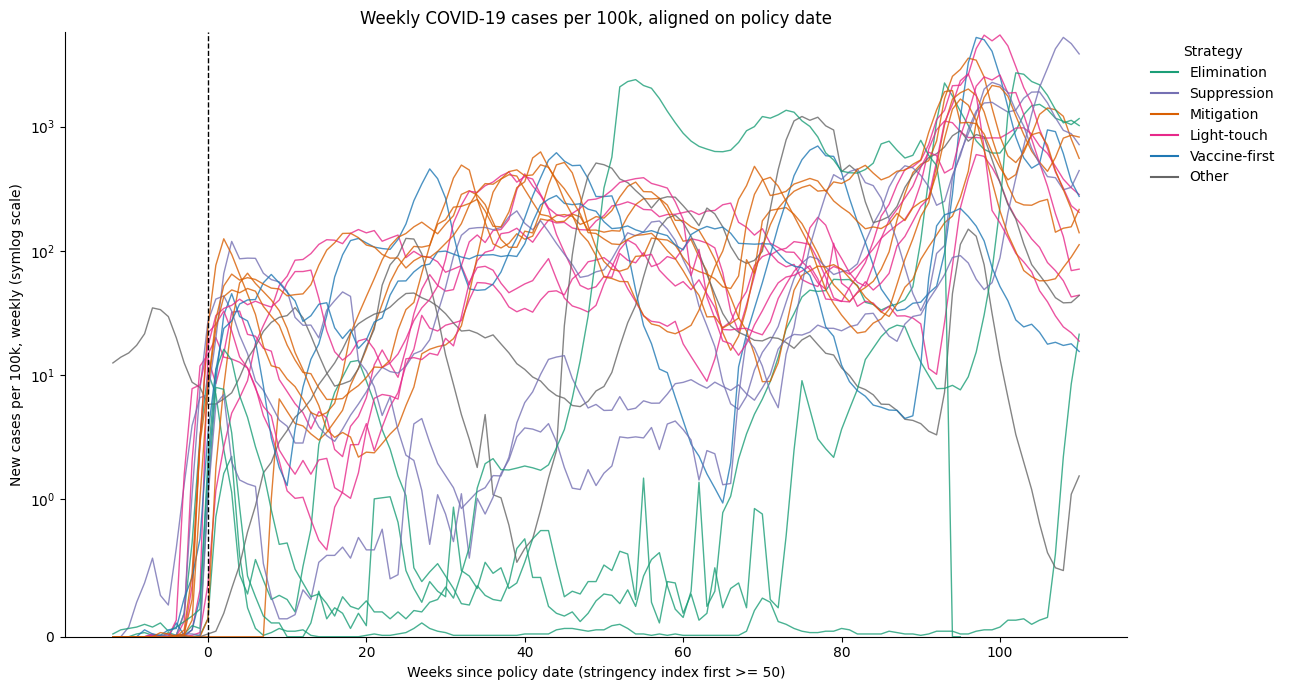

In [21]:


CSV = "covid_did_weekly.csv"
OUT = "cases_aligned_policy.png"
WINDOW = (-12, 110)  # weeks relative to policy date

df = pd.read_csv(CSV, parse_dates=["week_start"])

# Drop rows flagged as unreliable, and Tanzania (no reporting after 2020)
df = df[df.data_flag.isna() & (df.country != "Tanzania")]


def group(strategy):
    if strategy.startswith("Mitigation"):
        return "Mitigation"
    if strategy.startswith("Light"):
        return "Light-touch"
    return strategy


df["group"] = df.strategy.map(group)

colors = {
    "Elimination": "#1b9e77",
    "Suppression": "#7570b3",
    "Mitigation": "#d95f02",
    "Light-touch": "#e7298a",
    "Vaccine-first": "#1f78b4",
    "Other": "#666666",
}

fig, ax = plt.subplots(figsize=(13, 7))

for country, d in df.groupby("country"):
    d = d[d.event_time_s50.between(*WINDOW)]
    ax.plot(
        d.event_time_s50,
        d.new_cases_per_100k,
        color=colors[d.group.iloc[0]],
        lw=1,
        alpha=0.8,
    )

ax.axvline(0, color="black", ls="--", lw=1)  # policy date
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, None)
ax.set_xlabel("Weeks since policy date (stringency index first >= 50)")
ax.set_ylabel("New cases per 100k, weekly (symlog scale)")
ax.set_title("Weekly COVID-19 cases per 100k, aligned on policy date")

# Legend by strategy group, placed outside the axes
for name, color in colors.items():
    ax.plot([], [], color=color, label=name)
ax.legend(title="Strategy", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT, dpi=150)
plt.show()

,patient_id,diagnosis_date,disease_type,disease_stage,family_history,genetic_risk,hypertension,asthma,cirrhosis,other_cancer,treatment_type,medication_count,hospitalization_days,followup_visits,complication_status,post_treatment_weight,recovery_time_weeks,readmission_within_1yr,survived,followup_required
2,3,2021-02-04,Diabetes Complications,Stage IV,No,Medium,1,0,0,0,Radiation,7,40,6,1,100.7,23,0,1,0
5,6,2023-12-10,Diabetes Complications,Stage IV,No,High,1,0,0,1,Surgery,9,24,1,1,57.2,7,1,1,0
9,10,2022-01-22,Diabetes Complications,Stage II,No,High,0,0,1,1,Chemotherapy,8,12,0,1,106.7,17,0,1,1
11,12,2018-05-11,Diabetes Complications,Stage IV,No,High,1,0,0,1,Medication Only,0,33,6,1,61.5,24,0,1,1
18,19,2020-08-13,Diabetes Complications,Stage II,No,High,1,0,1,1,Medication Only,0,32,5,0,68.3,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11470,11471,2019-11-17,Diabetes Complications,Stage III,No,Medium,0,0,0,0,Radiation,8,34,5,0,108.4,29,0,0,0
11480,11481,2020-02-26,Diabetes Complications,Stage IV,Yes,Low,1,0,1,1,Radiation,4,47,11,0,89.3,12,0,1,1
11485,11486,2024-12-11,Diabetes Complications,Stage II,Yes,Medium,0,1,1,1,Radiation,4,9,4,0,78.9,12,0,1,1
11487,11488,2024-09-10,Diabetes Complications,Stage II,Yes,Low,0,0,0,1,Surgery,1,25,10,1,84.5,3,0,0,1
